# 📘 Day 11 — The Perceptron
> **Ashraf | IIT ISM**
---

##  — What is a Perceptron?

The **perceptron** is the simplest neural network unit, inspired by a biological neuron.

It computes a **weighted sum** of inputs, adds a **bias**, and passes the result through an **activation function**:

$$
\hat{y} = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

| Symbol | Meaning |
|--------|---------|
| $x_i$ | Input features |
| $w_i$ | Learned weights |
| $b$ | Bias term |
| $f(\cdot)$ | Activation function |
| $\hat{y}$ | Predicted output |

```
Inputs       Weights      Sum + Bias     Activation     Output
x₁ ──► w₁ ─┐
x₂ ──► w₂ ──► Σ(wᵢxᵢ + b) ──► f(·) ──► ŷ
x₃ ──► w₃ ─┘
```

> 💡 The perceptron is the **building block** of all modern neural networks.

## Activation Functions

The activation function introduces **non-linearity** into the model.

| Activation | Formula | Use Case |
|------------|---------|----------|
| **None (Identity)** | $f(x) = x$ | Regression |
| **Sigmoid** | $f(x) = \dfrac{1}{1+e^{-x}}$ | Probability output |
| **Step** | $f(x) = 1$ if $x \geq 0$ else $0$ | Hard binary classification |

> ⚠️ The step function is **non-differentiable** at 0 — gradient descent can't be used with it directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
class simplePerceptron:
    # Activation functions
    def __none(x):
        return x
    def __sigmoid(x):
        return 1/(1+np.exp(-x))
    def __step(x):
        out = np.zeros(x.shape)
        out[x >= 0] = 1
        return out

    possibleActivations = {
        'none': __none,
        'sigmoid': __sigmoid,
        'step': __step
    }

    def __init__(self, w=None, b_w=None, activation=None):
        self.w  = w   if w   is not None else 0
        self.b_w = b_w if b_w is not None else 0
        if (activation is None) or (activation not in self.possibleActivations):
            self.activation = 'none'
        else:
            self.activation = activation

    def setWs(self, w, b_w):
        self.w   = w
        self.b_w = b_w

    def predict(self, x):
        weightedSum = np.zeros(x.shape[0])
        for i in range(len(self.w)):
            weightedSum = self.w[i] * x[:, i]
        summed = weightedSum + (1 * self.b_w)
        return self.possibleActivations[self.activation](summed)

##  Test the Perceptron

Let's verify the perceptron works by passing a simple input array.

In [3]:
ourPerceptron = simplePerceptron(w=[0], b_w=1, activation='none')
ourPerceptron.setWs([1], 0)

testInput = np.array([[100, -1, 0.1]]).T
print("Prediction:", ourPerceptron.predict(testInput))

Prediction: [100.   -1.    0.1]


## The Iris Dataset (Classification)

The **Iris dataset** has 3 flower classes. A basic perceptron can only learn a **linear boundary**, so we:

1. ✂️ **Drop Virginica** → binary problem (Setosa vs Versicolor)
2. 📐 **Use 2 features only** → sepal length & width
3. 🔀 **Shuffle** the data → prevent ordering bias

This gives us a **linearly separable** dataset the perceptron can solve.

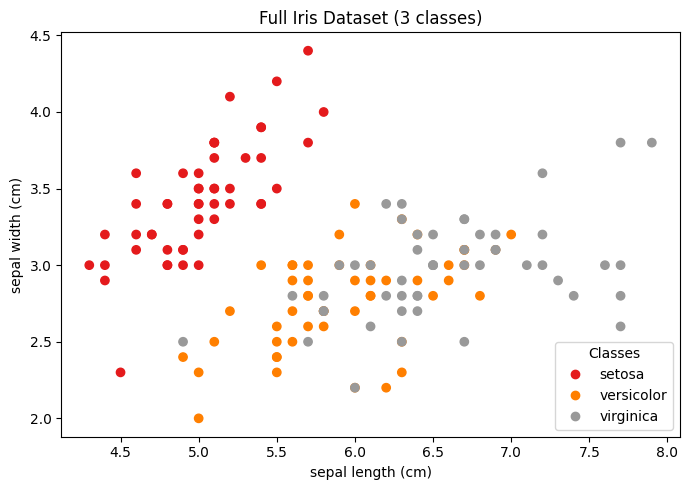

In [4]:
from sklearn import datasets

iris = datasets.load_iris()

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target, cmap='Set1')
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1],
       title='Full Iris Dataset (3 classes)')
ax.legend(scatter.legend_elements()[0], iris.target_names,
          loc="lower right", title="Classes")
plt.tight_layout()
plt.show()

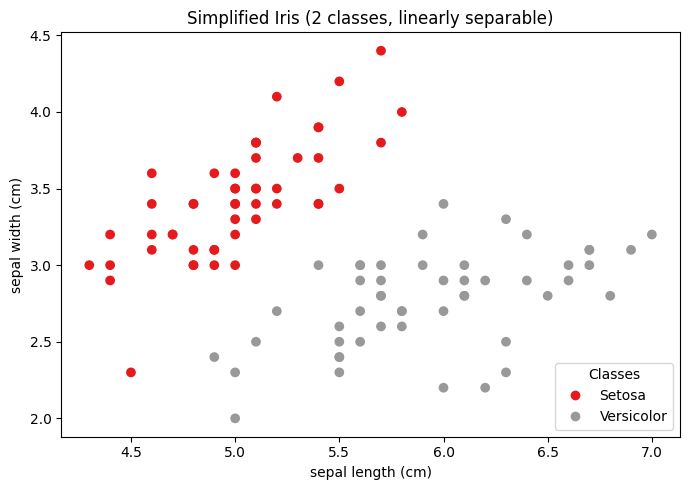

In [5]:
# Keep only Setosa & Versicolor, only sepal features
simpleInputs  = iris.data[iris.target != 2, 0:2]
simpleOutputs = iris.target[iris.target != 2]

# Shuffle
rng = np.random.default_rng(seed=42)
p = rng.permutation(len(simpleInputs))
simpleInputs  = simpleInputs[p, :]
simpleOutputs = simpleOutputs[p]

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(simpleInputs[:, 0], simpleInputs[:, 1],
                     c=simpleOutputs, cmap='Set1')
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1],
       title='Simplified Iris (2 classes, linearly separable)')
ax.legend(scatter.legend_elements()[0], ['Setosa', 'Versicolor'],
          loc='lower right', title='Classes')
plt.tight_layout()
plt.show()

##  The Perceptron Learning Rule

The perceptron updates weights after **each individual sample** (online learning):

$$
w_i^{\text{new}} = w_i + \eta \cdot (y - \hat{y}) \cdot x_i
$$
$$
b^{\text{new}} = b + \eta \cdot (y - \hat{y})
$$

| Symbol | Meaning |
|--------|---------|
| $\eta$ | Learning rate |
| $y$ | True label |
| $\hat{y}$ | Predicted label |
| $x_i$ | Input value |

**Intuition:**
- Correct prediction → no change (error = 0)
- Prediction too low → increase weights
- Prediction too high → decrease weights

> 🔁 This is an **online algorithm** — one update per sample per iteration.

In [6]:
percept = simplePerceptron(w=np.array([0, 0]).T, b_w=0, activation='step')

iterations  = 100
learningRate = 0.0001
whichItem    = 0

for i in range(iterations):
    thisInput  = np.reshape(simpleInputs[whichItem, :], (1, -1))
    thisTarget = simpleOutputs[whichItem]
    out   = percept.predict(thisInput)
    error = thisTarget - out

    newWeights = np.zeros(percept.w.size)
    for j in range(len(percept.w)):
        update = learningRate * error * thisInput[:, j]
        newWeights[j] = percept.w[j] + float(update)

    percept.setWs(newWeights, percept.b_w + float(learningRate * error))
    whichItem += 1

print("Trained weights:", percept.w)
print("Trained bias   :", percept.b_w)

Trained weights: [ 0.00509 -0.00038]
Trained bias   : 0.0004


/tmp/ipykernel_12199/1655765830.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  newWeights[j] = percept.w[j] + float(update)
/tmp/ipykernel_12199/1655765830.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  percept.setWs(newWeights, percept.b_w + float(learningRate * error))


## 📊 Visualise the Decision Boundary

After training, we plot the **decision region** to see how the perceptron separates the two classes.

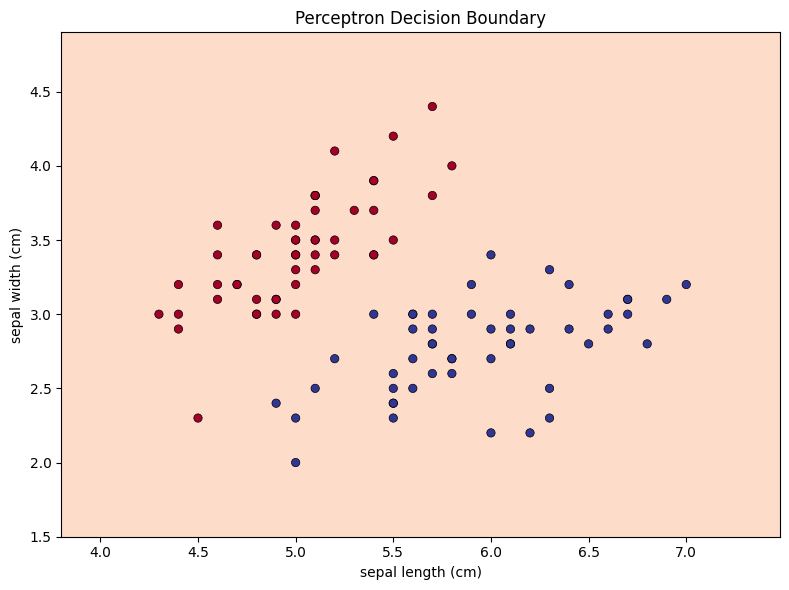

In [7]:
# Manually plot decision region (avoids mlxtend dependency issues)
h  = 0.02
x_min, x_max = simpleInputs[:, 0].min() - 0.5, simpleInputs[:, 0].max() + 0.5
y_min, y_max = simpleInputs[:, 1].min() - 0.5, simpleInputs[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid   = np.c_[xx.ravel(), yy.ravel()]
Z      = percept.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
ax.scatter(simpleInputs[:, 0], simpleInputs[:, 1],
           c=simpleOutputs, cmap='RdYlBu', edgecolors='k', linewidths=0.5)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1],
       title='Perceptron Decision Boundary')
plt.tight_layout()
plt.show()

##  Cost Function: Mean Squared Error

For regression, we measure quality with **MSE**:

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

| Property | Detail |
|----------|--------|
| **Range** | $[0, \infty)$ — lower is better |
| **Perfect fit** | MSE = 0 |
| **Penalises large errors** | Squared term amplifies outliers |
| **Differentiable** | Enables gradient-based optimisation |

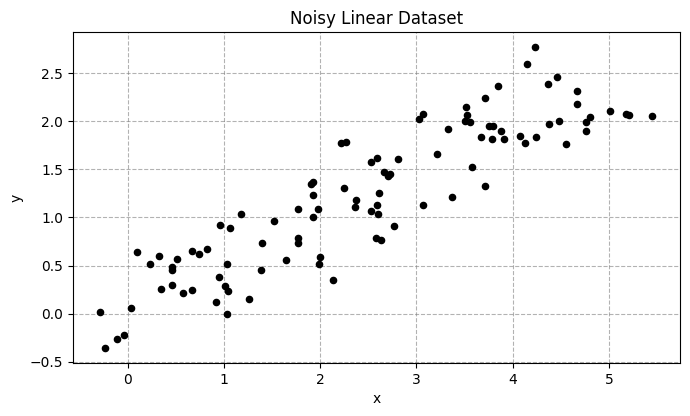

In [7]:
# Create a noisy linear dataset
num = 100
xRange = [0, 5]
yRange = [0, 2.5]

x = np.linspace(xRange[0], xRange[1], num=num)
y = np.linspace(yRange[0], yRange[1], num=num)

noise_factor = 0.5
def noise(k):
    return k + ((rng.random() * 2) - 1) * noise_factor

x = np.vectorize(noise)(x)
y = np.vectorize(noise)(y)

p = rng.permutation(num)
x = x[p]
y = y[p]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color='k', s=20)
ax.set_aspect('equal')
ax.set_axisbelow(True)
ax.grid(color='gray', linestyle='dashed', alpha=0.6)
ax.set(title='Noisy Linear Dataset', xlabel='x', ylabel='y')
plt.tight_layout()
plt.show()

In [8]:
def mseCost(prediction, target):
    return (np.square(prediction - target)).mean()

# Test: perfect prediction → MSE = 0
print("MSE (perfect):", mseCost(y, y))

MSE (perfect): 0.0


##  Gradient Descent

Gradient descent iteratively adjusts weights to **minimise the cost function**.

$$
w \leftarrow w + \eta \cdot X^T (y - \hat{y})
$$
$$
b \leftarrow b + \eta \cdot \sum(y - \hat{y})
$$

### Algorithm

```
1. Initialise weights → 0
2. For each iteration:
   a.  Predict   ŷ = f(Xw + b)
   b.  Error     e = y − ŷ
   c.  Update    w ← w + η · Xᵀe
   d.  Update    b ← b + η · Σe
   e.  Check stopping criterion  |C_t − C_{t−1}| ≤ ε
3. Return weights
```

> 🎛️ **Hyperparameters** (learning rate $\eta$, iterations, threshold $\varepsilon$) must be manually tuned.

In [9]:
def gradientDescent(perceptron, costFunction, trainInput, trainTarget,
                    learningRate, numIterations, stoppingCriterion):
    weights, biases, costs = [], [], []
    previousCost = None

    for i in range(numIterations):
        prediction = perceptron.predict(trainInput)
        thisCost   = costFunction(prediction, trainTarget)

        if previousCost and np.absolute(previousCost - thisCost) <= stoppingCriterion:
            break
        previousCost = thisCost

        weights.append(perceptron.w.copy())
        biases.append(perceptron.b_w)
        costs.append(thisCost)

        er = np.subtract(trainTarget, prediction)
        weightUpdate     = learningRate * np.dot(trainInput.T, er)
        biasWeightUpdate = learningRate * np.sum(er)
        perceptron.setWs(perceptron.w + weightUpdate,
                         perceptron.b_w + biasWeightUpdate)

    return {'weights': weights, 'biases': biases, 'costs': costs}

# Run gradient descent
ourPerceptron.setWs([0], 0)
output = gradientDescent(ourPerceptron, mseCost,
                         np.reshape(x[0:50], (-1, 1)), y[0:50],
                         learningRate=0.001,
                         numIterations=10000,
                         stoppingCriterion=1e-6)

print(f"Converged in {len(output['costs'])} iterations")
print(f"Final weight: {ourPerceptron.w},  bias: {ourPerceptron.b_w:.4f}")

Converged in 124 iterations
Final weight: [0.42075346],  bias: 0.1867


## 📈 Training Progress

Plot how **weights**, **bias**, and **cost** evolve over iterations.

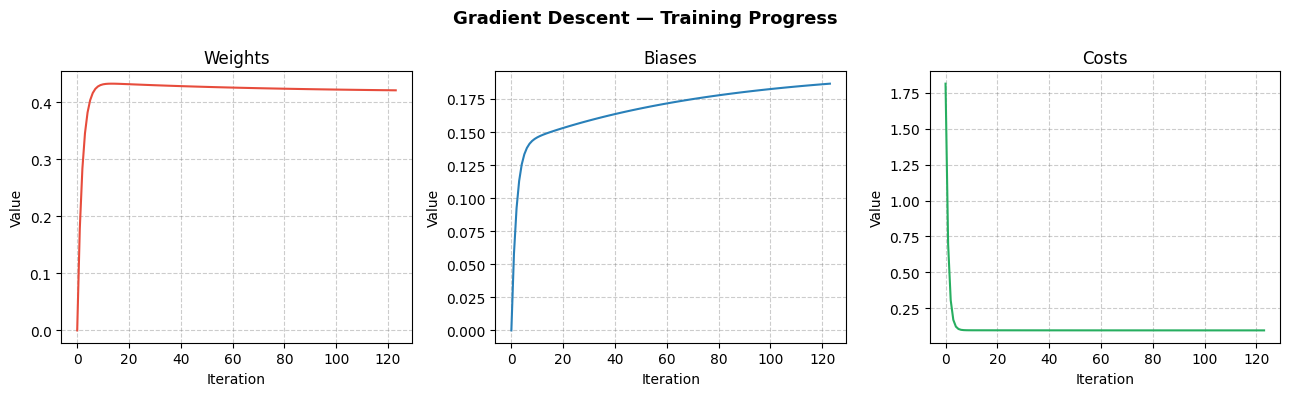

In [10]:
def plotOutputs(gdOutput):
    iterationsRan = len(gdOutput['costs'])
    toPlot = ['weights', 'biases', 'costs']
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    colors = ['#e74c3c', '#2980b9', '#27ae60']
    for i, (key, col) in enumerate(zip(toPlot, colors)):
        axes[i].plot(range(iterationsRan), gdOutput[key], color=col, linewidth=1.5)
        axes[i].set_xlabel('Iteration')
        axes[i].set_ylabel('Value')
        axes[i].set_title(key.capitalize())
        axes[i].grid(color='gray', linestyle='dashed', alpha=0.4)
    fig.suptitle('Gradient Descent — Training Progress', fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

plotOutputs(output)
plt.show()

##  Perceptron vs Ordinary Least Squares (OLS)

| Aspect | Perceptron (Gradient Descent) | OLS (Analytical) |
|--------|-------------------------------|------------------|
| **Method** | Iterative optimisation | Closed-form: $w=(X^TX)^{-1}X^Ty$ |
| **Exact solution?** | Approximate | ✅ Exact |
| **Large datasets** | ✅ Scalable | ❌ Matrix inversion costly |
| **Extensible** | ✅ Basis of deep learning | ❌ Linear models only |

> 💡 OLS is optimal for simple linear regression, but gradient descent **scales** to neural networks.

Test MSE (perceptron): 1.047800


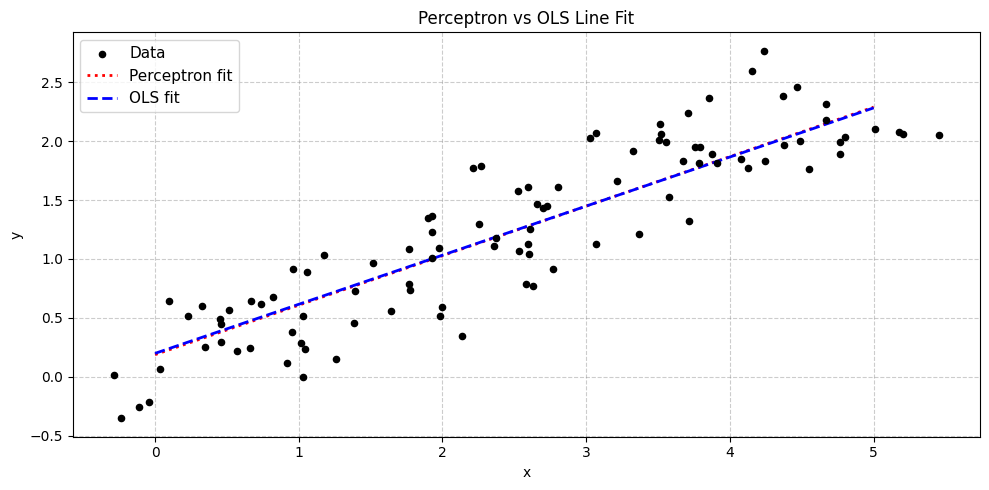

In [11]:
# Evaluate on unseen test data
testPredictions = ourPerceptron.predict(np.reshape(x[50:100], (-1, 1)))
testCost = mseCost(testPredictions, np.reshape(y[50:100], (-1, 1)))
print(f'Test MSE (perceptron): {testCost:.6f}')

def compareOutputs(x, y, perceptron, xRange):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(x, y, color='k', s=20, label='Data', zorder=3)
    forLine = np.linspace(xRange[0], xRange[1])

    # Perceptron fit
    ax.plot(forLine, perceptron.predict(np.reshape(forLine, (-1, 1))),
            color='red', linestyle='dotted', linewidth=2, label='Perceptron fit')

    # OLS fit
    OLS = LinearRegression().fit(x[0:50].reshape(-1, 1), y[0:50])
    ax.plot(forLine, OLS.predict(forLine.reshape(-1, 1)),
            color='blue', linestyle='dashed', linewidth=2, label='OLS fit')

    ax.set_axisbelow(True)
    ax.grid(color='gray', linestyle='dashed', alpha=0.4)
    ax.legend(fontsize=11)
    ax.set(title='Perceptron vs OLS Line Fit', xlabel='x', ylabel='y')
    fig.tight_layout()
    return fig

compareOutputs(x, y, ourPerceptron, xRange)
plt.show()

## Hyperparameter Effects

| Hyperparameter | Too Small | Just Right | Too Large |
|----------------|-----------|------------|-----------|
| **Learning Rate $\eta$** | Slow convergence | Fast, stable | Overshooting / divergence |
| **Iterations** | Under-fitted | Converged | Wasted compute |
| **Stopping $\varepsilon$** | Precise but slow | Balanced | Stops too early |
| **Init weights** | Near-optimal start | Fast convergence | Can get stuck |

> 🧪 Always experiment with different values — there is no single best choice.

## 🔁 Hyperparameter Sweep

Manually vary learning rate and observe convergence behaviour.

/tmp/ipykernel_12199/42052275.py:2: RuntimeWarning: overflow encountered in square
  return (np.square(prediction - target)).mean()
/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/geo_env/lib/python3.10/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_12199/1172206313.py:10: RuntimeWarning: invalid value encountered in scalar subtract
  if previousCost and np.absolute(previousCost - thisCost) <= stoppingCriterion:
/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/geo_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_12199/4265718056.py:34: RuntimeWarning: invalid value encountered in add
  summed = weightedSum + (1 * self.b_w)


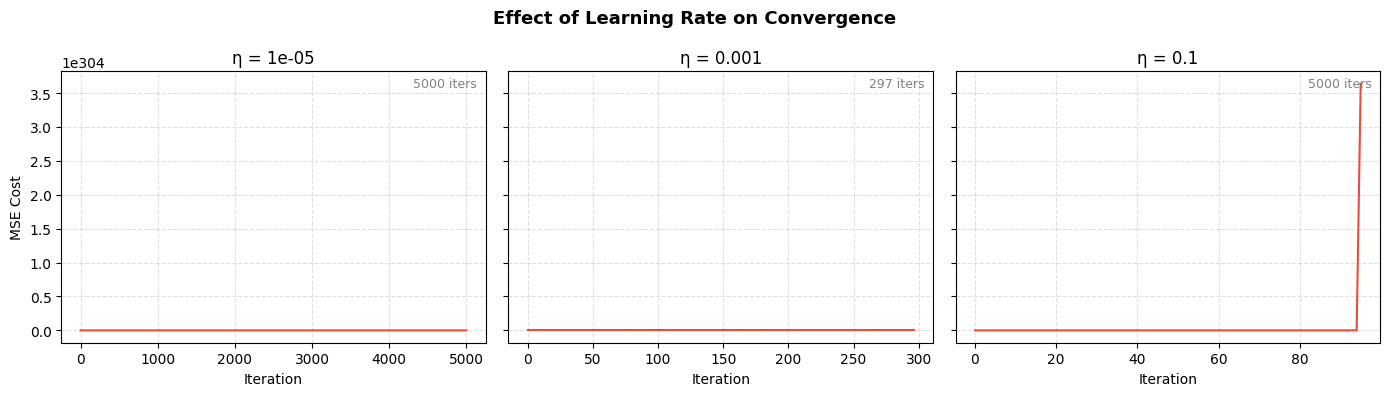

In [12]:
learning_rates = [1e-5, 1e-3, 1e-1]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, lr in zip(axes, learning_rates):
    p = simplePerceptron(w=[0], b_w=0, activation='none')
    out = gradientDescent(p, mseCost,
                          np.reshape(x[0:50], (-1, 1)), y[0:50],
                          learningRate=lr, numIterations=5000,
                          stoppingCriterion=1e-8)
    ax.plot(out['costs'], color='#e74c3c', linewidth=1.5)
    ax.set_title(f'η = {lr}', fontsize=12)
    ax.set_xlabel('Iteration')
    ax.grid(alpha=0.4, linestyle='dashed')
    ax.text(0.98, 0.98, f"{len(out['costs'])} iters",
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color='gray')

axes[0].set_ylabel('MSE Cost')
fig.suptitle('Effect of Learning Rate on Convergence', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [14]:
!pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 KB 72.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 KB 108.0 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 219.2 kB/s eta 0:00:0000:0100:01


## 🔑 Summary

```
┌──────────────────────────────────────────────────────────┐
│                  DAY 11 — KEY TAKEAWAYS                  │
├──────────────────────────────────────────────────────────┤
│  ✅ Perceptron = weighted sum + bias + activation        │
│  ✅ Activation shapes the output (step / sigmoid / none) │
│  ✅ Perceptron rule: online, error-driven update         │
│  ✅ Gradient descent: batch, cost-minimising update      │
│  ✅ MSE measures regression fit                          │
│  ✅ Hyperparameters (η, ε, iters) need tuning            │
│  ✅ Perceptron ≈ OLS for linear regression               │
│  ✅ Perceptron is the foundation of neural networks      │
└──────────────────────────────────────────────────────────┘
```

> 🚀 **Next:** Day 12 — Neural Networks build on this single unit to learn complex non-linear functions using **multiple layers**.